<a href="https://colab.research.google.com/github/rishitmiglani2006-web/Gender_classification/blob/main/Gender_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision
!pip install opencv-python

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [5]:
!file /content/archive.zip

/content/archive.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [6]:
import os

print("Size:", os.path.getsize("/content/archive.zip") / (1024*1024), "MB")

Size: 156.0 MB


In [7]:
!unzip -q /content/archive.zip -d /content/dataset

In [8]:
import os

print(os.listdir('/content/dataset'))

['utkface_aligned_cropped', 'UTKFace', 'crop_part1']


In [9]:
print(os.listdir('/content/dataset'))

['utkface_aligned_cropped', 'UTKFace', 'crop_part1']


In [10]:
!find /content/dataset -type f | head -10

/content/dataset/utkface_aligned_cropped/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_0_0_20170112215240346.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170110183726390.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170112213001988.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170112213303693.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170112215032192.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170117195420803.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170119212053665.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_2_20170105174847679.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_2_20170112213615815.jpg.chip.jpg


In [11]:
!find /content/dataset -type f | wc -l

66976


In [12]:
dataset_path = "/content/dataset/utkface_aligned_cropped/UTKFace"

In [13]:
import os

files = os.listdir(dataset_path)

print("Total images:", len(files))
print(files[:5])

Total images: 23708
['47_1_0_20170119192708105.jpg.chip.jpg', '29_1_0_20170117005833085.jpg.chip.jpg', '14_0_0_20170110232633429.jpg.chip.jpg', '18_1_0_20170109212906609.jpg.chip.jpg', '26_0_1_20170116204840434.jpg.chip.jpg']


In [14]:
!pip install opencv-python

In [15]:
import cv2
import matplotlib.pyplot as plt

image_path = os.path.join(dataset_path, files[0])

image = cv2.imread(image_path)

print(image.shape)

(200, 200, 3)


In [16]:
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

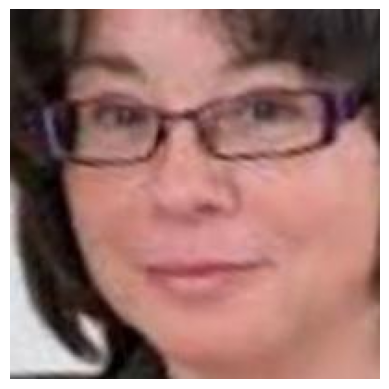

In [17]:
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

In [18]:
def get_gender(filename):
    return int(filename.split("_")[1])

In [19]:
for i in range(5):
    file = files[i]

    gender = get_gender(file)

    print(file)
    print("Gender:", gender)
    print()

47_1_0_20170119192708105.jpg.chip.jpg
Gender: 1

29_1_0_20170117005833085.jpg.chip.jpg
Gender: 1

14_0_0_20170110232633429.jpg.chip.jpg
Gender: 0

18_1_0_20170109212906609.jpg.chip.jpg
Gender: 1

26_0_1_20170116204840434.jpg.chip.jpg
Gender: 0



In [20]:
labels = []

for file in files:
    labels.append(get_gender(file))

In [21]:
print(labels[:10])

[1, 1, 0, 1, 0, 1, 0, 0, 1, 1]


In [22]:
print(files[:5])
print(labels[:5])

['47_1_0_20170119192708105.jpg.chip.jpg', '29_1_0_20170117005833085.jpg.chip.jpg', '14_0_0_20170110232633429.jpg.chip.jpg', '18_1_0_20170109212906609.jpg.chip.jpg', '26_0_1_20170116204840434.jpg.chip.jpg']
[1, 1, 0, 1, 0]


In [23]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [24]:
import cv2
import os

image_path = os.path.join(dataset_path, files[0])

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

tensor_image = transform(image)

print(tensor_image.shape)

torch.Size([3, 128, 128])


In [25]:
from torch.utils.data import Dataset
import torch

class GenderDataset(Dataset):

    def __init__(self, folder, transform=None):
        self.folder = folder
        self.files = os.listdir(folder)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        image_path = os.path.join(
            self.folder,
            filename
        )

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        gender = int(
            filename.split("_")[1]
        )

        if self.transform:
            image = self.transform(image)

        return image, gender

In [26]:
dataset = GenderDataset(
    dataset_path,
    transform=transform
)

In [27]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([3, 128, 128])
1


In [28]:
print(tensor_image.shape)

torch.Size([3, 128, 128])


In [29]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [30]:
images, labels = next(iter(loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


In [31]:
torch.Size([32, 3, 128, 128])
torch.Size([32])

torch.Size([32])